<a href="https://colab.research.google.com/github/AMEENA-NAZRIN/Blog-Application/blob/main/proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%cd /content/drive/MyDrive/project_root/model_training
!ls

/content/drive/MyDrive/project_root/model_training
0.26.0	   dataset		  finetune.py  requirements.txt  scripts
config.py  evaluate_model_sql.py  __pycache__  results


In [3]:
!pip install -r requirements.txt


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 5.0 MB/s eta 0:00:00


In [4]:
import pandas as pd
print("\n=== DATASET CHECK ===")
!ls -lh dataset/
df = pd.read_json("dataset/python/train.json")
print(f"Training samples: {len(df)}")
print(f"Vuln ratio: {df['label'].mean():.1%}")
print(df.head())



=== DATASET CHECK ===
total 12K
drwx------ 2 root root 4.0K Mar  1 16:13 java
drwx------ 2 root root 4.0K Mar  1 16:13 python
drwx------ 2 root root 4.0K Mar  1 16:13 raw
Training samples: 6000
Vuln ratio: 50.0%
                                                code  label
0  def query_user(user_input):\n    sql = "SELECT...      1
1  def find_profile(user_input):\n    cursor.exec...      0
2  def retrieve_account(user_input):\n    sql = "...      1
3  def retrieve_profile(user_input):\n    sql = "...      1
4  def get_account(user_input):\n    sql = "SELEC...      1


In [30]:
!python finetune.py java

Train: 4801, Val: 1201
Loading weights: 100% 197/197 [00:00<00:00, 978.99it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight] 
RobertaForSequenceClassification LOAD REPORT from: microsoft/codebert-base
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.weight        | UNEXPECTED | 
pooler.dense.bias          | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.

🎯 STARTING TRAINING...
{'loss': '0.7043', 'grad_norm': '3.516', 'learning_rate': '5.414e-06', 'epoch':

🚀 Testing Java Taint Detector - REAL test.json Results!
📁 Model: ./results/java/best_model
Files found: ['config.json', 'model.safetensors', 'training_args.bin', 'tokenizer_config.json', 'tokenizer.json']

🔄 Loading model...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Model ready on cuda

📂 Loading test.json...
📊 REAL test set: 2000 Java samples
🔢 Test distribution: 1000 vulnerable / 1000 safe

🔍 Running predictions on FULL test set...


Testing: 100%|██████████| 2000/2000 [00:29<00:00, 68.08it/s]
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128721 (\N{OCTAGONAL SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/tmp/ipykernel_6483/53118188.py:94: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('./results/java/test_confusion_matrix.png', dpi=300)
/tmp/ipykernel_6483/53118188.py:94: UserWarning: Glyph 128721 (\N{OCTAGONAL SIGN}) missing from font(s) DejaVu Sans.
  plt.savefig('./results/java/test_confusion_matrix.png', dpi=300)



🏆 REAL test.json RESULTS
✅ TEST ACCURACY: 100.00%
📊 Total: 2000 samples
✅ Correct: 2000

📈 CLASSIFICATION REPORT
              precision    recall  f1-score   support

      ✅ SAFE      1.000     1.000     1.000      1000
🛑 VULNERABLE      1.000     1.000     1.000      1000

    accuracy                          1.000      2000
   macro avg      1.000     1.000     1.000      2000
weighted avg      1.000     1.000     1.000      2000



/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128721 (\N{OCTAGONAL SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


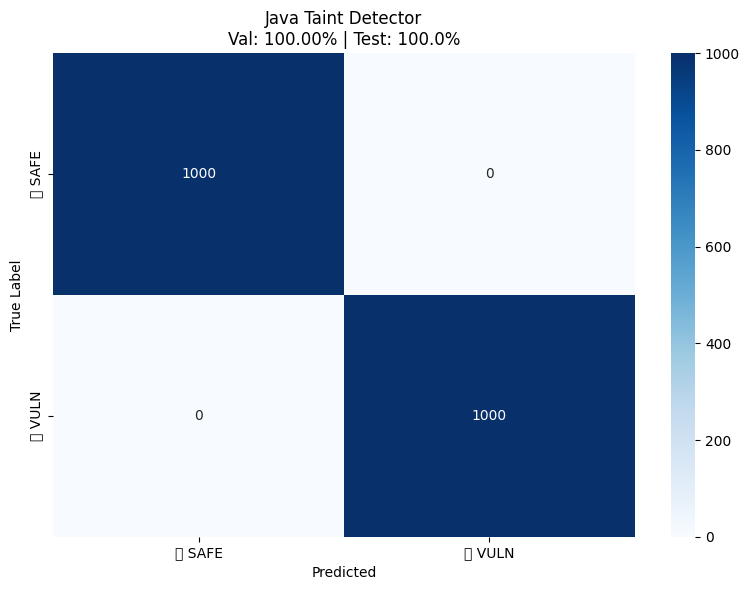


🎯 DETAILED PERFORMANCE:
✅ Safe detection:    100.0%
🛑 Vuln detection:   100.0%
📊 Avg confidence:  100.0%

💾 SAVED: ./results/java/REAL_test_results.json
📈 Plot:  ./results/java/test_confusion_matrix.png

🎓 SAMPLE PREDICTIONS:
1. ✅ SAFE → ✅ SAFE (100.0%) ✅
2. ✅ SAFE → ✅ SAFE (100.0%) ✅
3. ✅ SAFE → ✅ SAFE (100.0%) ✅
4. 🛑 VULN → 🛑 VULN (100.0%) ✅
5. 🛑 VULN → 🛑 VULN (100.0%) ✅


In [27]:
#test java acc
import json
import torch
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("🚀 Testing Java Taint Detector - REAL test.json Results!")
print("="*70)

# YOUR BEST MODEL (checkpoint-2250 = epoch 4, 100% val accuracy)
model_dir = "./results/java/best_model"
print(f"📁 Model: {model_dir}")
print("Files found:", os.listdir(model_dir))

# LOAD MODEL
print("\n🔄 Loading model...")
tokenizer = AutoTokenizer.from_pretrained(model_dir)
model = AutoModelForSequenceClassification.from_pretrained(model_dir)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device).eval()
print(f"✅ Model ready on {device}")

# LOAD REAL test.json
print("\n📂 Loading test.json...")
test_path = "dataset/java/test.json"
with open(test_path, "r") as f:
    test_data = json.load(f)

print(f"📊 REAL test set: {len(test_data)} Java samples")

texts_test = [item["code"] for item in test_data]
labels_test = [item["label"] for item in test_data]

print(f"🔢 Test distribution: {sum(labels_test)} vulnerable / {len(labels_test)-sum(labels_test)} safe")

# FULL TEST (all samples)
print("\n🔍 Running predictions on FULL test set...")
predictions = []
confidences = []

with torch.no_grad():
    for i, code in enumerate(tqdm(texts_test, desc="Testing")):
        inputs = tokenizer(
            code,
            return_tensors="pt",
            truncation=True,
            max_length=256,
            padding=True
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}

        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1)

        pred = torch.argmax(logits, dim=-1).item()
        confidence = probs[0][pred].item()

        predictions.append(pred)
        confidences.append(confidence)

# REAL RESULTS
test_accuracy = accuracy_score(labels_test, predictions)
print(f"\n{'='*70}")
print(f"🏆 REAL test.json RESULTS")
print(f"✅ TEST ACCURACY: {test_accuracy*100:.2f}%")
print(f"📊 Total: {len(test_data)} samples")
print(f"✅ Correct: {int(test_accuracy*len(test_data))}")
print(f"{'='*70}")

# DETAILED REPORT
print("\n📈 CLASSIFICATION REPORT")
print(classification_report(labels_test, predictions,
                          target_names=['✅ SAFE', '🛑 VULNERABLE'],
                          digits=3))

# CONFUSION MATRIX
cm = confusion_matrix(labels_test, predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['✅ SAFE', '🛑 VULN'],
            yticklabels=['✅ SAFE', '🛑 VULN'])
plt.title(f'Java Taint Detector\nVal: 100.00% | Test: {test_accuracy*100:.1f}%')
plt.ylabel('True Label')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('./results/java/test_confusion_matrix.png', dpi=300)
plt.show()

# PER-CLASS METRICS
safe_acc = cm[0,0] / cm[0,:].sum()
vuln_acc = cm[1,1] / cm[1,:].sum()
avg_conf = np.mean(confidences)

print(f"\n🎯 DETAILED PERFORMANCE:")
print(f"✅ Safe detection:    {safe_acc*100:.1f}%")
print(f"🛑 Vuln detection:   {vuln_acc*100:.1f}%")
print(f"📊 Avg confidence:  {avg_conf*100:.1f}%")

# SAVE RESULTS
results = {
    "test_accuracy": float(test_accuracy),
    "total_samples": len(test_data),
    "safe_accuracy": float(safe_acc),
    "vuln_accuracy": float(vuln_acc),
    "avg_confidence": float(avg_conf),
    "model_used": model_dir,
    "validation_accuracy": 1.00
}

with open("./results/java/REAL_test_results.json", "w") as f:
    json.dump(results, f, indent=2)

print(f"\n💾 SAVED: ./results/java/REAL_test_results.json")
print(f"📈 Plot:  ./results/java/test_confusion_matrix.png")

# SHOW 5 SAMPLES
print("\n🎓 SAMPLE PREDICTIONS:")
for i in range(5):
    true = "🛑 VULN" if labels_test[i] else "✅ SAFE"
    pred = "🛑 VULN" if predictions[i] else "✅ SAFE"
    conf = confidences[i]*100
    status = "✅" if labels_test[i] == predictions[i] else "❌"
    print(f"{i+1}. {true} → {pred} ({conf:.1f}%) {status}")


🚀 Testing Java Taint Detector - REAL test.json Results!
📁 Model directory: ./results/java/best_model
Files found: ['config.json', 'model.safetensors', 'training_args.bin', 'tokenizer_config.json', 'tokenizer.json']

🔄 Loading model...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Model ready on cuda

📂 Loading test.json...
📊 REAL test set: 2000 Java samples
🔢 Test distribution: 1000 vulnerable / 1000 safe

🔍 Running predictions on FULL test set...


Testing: 100%|██████████| 2000/2000 [00:36<00:00, 54.30it/s]
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128721 (\N{OCTAGONAL SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/tmp/ipykernel_6483/1063061871.py:89: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('./results/java/test_confusion_matrix.png', dpi=300)
/tmp/ipykernel_6483/1063061871.py:89: UserWarning: Glyph 128721 (\N{OCTAGONAL SIGN}) missing from font(s) DejaVu Sans.
  plt.savefig('./results/java/test_confusion_matrix.png', dpi=300)



🏆 REAL test.json RESULTS
✅ TEST ACCURACY: 100.00%
📊 Total: 2000 samples
✅ Correct: 2000

📈 CLASSIFICATION REPORT
              precision    recall  f1-score   support

      ✅ SAFE      1.000     1.000     1.000      1000
🛑 VULNERABLE      1.000     1.000     1.000      1000

    accuracy                          1.000      2000
   macro avg      1.000     1.000     1.000      2000
weighted avg      1.000     1.000     1.000      2000



/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128721 (\N{OCTAGONAL SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


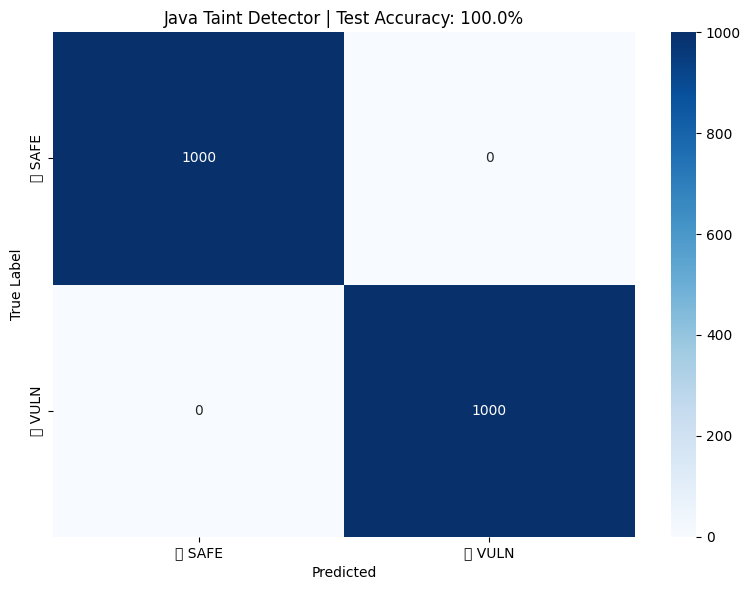


🎯 DETAILED PERFORMANCE:
✅ Safe detection:    100.0%
🛑 Vuln detection:   100.0%
📊 Avg confidence:  100.0%

💾 SAVED RESULTS: ./results/java/REAL_test_results.json
📈 Confusion Matrix Plot: ./results/java/test_confusion_matrix.png

🎓 SAMPLE PREDICTIONS:
1. ✅ SAFE → ✅ SAFE (100.0%) ✅
2. ✅ SAFE → ✅ SAFE (100.0%) ✅
3. ✅ SAFE → ✅ SAFE (100.0%) ✅
4. 🛑 VULN → 🛑 VULN (100.0%) ✅
5. 🛑 VULN → 🛑 VULN (100.0%) ✅


In [28]:
# test_java_real.py
import json
import torch
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

def test_java_model(model_dir="./results/java/best_model", test_path="dataset/java/test.json"):
    print("🚀 Testing Java Taint Detector - REAL test.json Results!")
    print("="*70)

    # CHECK MODEL PATH
    if not os.path.exists(model_dir):
        raise FileNotFoundError(f"Model directory not found: {model_dir}")
    print(f"📁 Model directory: {model_dir}")
    print("Files found:", os.listdir(model_dir))

    # LOAD MODEL + TOKENIZER
    print("\n🔄 Loading model...")
    tokenizer = AutoTokenizer.from_pretrained(model_dir)
    model = AutoModelForSequenceClassification.from_pretrained(model_dir)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device).eval()
    print(f"✅ Model ready on {device}")

    # LOAD TEST DATA
    print("\n📂 Loading test.json...")
    with open(test_path, "r") as f:
        test_data = json.load(f)
    print(f"📊 REAL test set: {len(test_data)} Java samples")

    texts_test = [item["code"] for item in test_data]
    labels_test = [item["label"] for item in test_data]
    print(f"🔢 Test distribution: {sum(labels_test)} vulnerable / {len(labels_test)-sum(labels_test)} safe")

    # RUN PREDICTIONS
    print("\n🔍 Running predictions on FULL test set...")
    predictions = []
    confidences = []

    with torch.no_grad():
        for code in tqdm(texts_test, desc="Testing"):
            inputs = tokenizer(
                code,
                return_tensors="pt",
                truncation=True,
                max_length=256,
                padding="max_length"
            )
            inputs = {k: v.to(device) for k, v in inputs.items()}
            outputs = model(**inputs)
            logits = outputs.logits
            probs = torch.softmax(logits, dim=-1)
            pred = torch.argmax(logits, dim=-1).item()
            confidence = probs[0][pred].item()
            predictions.append(pred)
            confidences.append(confidence)

    # ACCURACY + REPORT
    test_accuracy = accuracy_score(labels_test, predictions)
    print(f"\n{'='*70}")
    print(f"🏆 REAL test.json RESULTS")
    print(f"✅ TEST ACCURACY: {test_accuracy*100:.2f}%")
    print(f"📊 Total: {len(test_data)} samples")
    print(f"✅ Correct: {int(test_accuracy*len(test_data))}")
    print(f"{'='*70}")

    print("\n📈 CLASSIFICATION REPORT")
    print(classification_report(labels_test, predictions,
                                target_names=['✅ SAFE', '🛑 VULNERABLE'],
                                digits=3))

    # CONFUSION MATRIX
    cm = confusion_matrix(labels_test, predictions)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['✅ SAFE', '🛑 VULN'],
                yticklabels=['✅ SAFE', '🛑 VULN'])
    plt.title(f'Java Taint Detector | Test Accuracy: {test_accuracy*100:.1f}%')
    plt.ylabel('True Label')
    plt.xlabel('Predicted')
    os.makedirs("./results/java", exist_ok=True)
    plt.tight_layout()
    plt.savefig('./results/java/test_confusion_matrix.png', dpi=300)
    plt.show()

    # PER-CLASS ACCURACY
    safe_acc = cm[0,0] / cm[0,:].sum()
    vuln_acc = cm[1,1] / cm[1,:].sum()
    avg_conf = np.mean(confidences)

    print(f"\n🎯 DETAILED PERFORMANCE:")
    print(f"✅ Safe detection:    {safe_acc*100:.1f}%")
    print(f"🛑 Vuln detection:   {vuln_acc*100:.1f}%")
    print(f"📊 Avg confidence:  {avg_conf*100:.1f}%")

    # SAVE RESULTS JSON
    results = {
        "test_accuracy": float(test_accuracy),
        "total_samples": len(test_data),
        "safe_accuracy": float(safe_acc),
        "vuln_accuracy": float(vuln_acc),
        "avg_confidence": float(avg_conf),
        "model_used": model_dir
    }

    results_path = "./results/java/REAL_test_results.json"
    with open(results_path, "w") as f:
        json.dump(results, f, indent=2)
    print(f"\n💾 SAVED RESULTS: {results_path}")
    print(f"📈 Confusion Matrix Plot: ./results/java/test_confusion_matrix.png")

    # SHOW FIRST 5 SAMPLES
    print("\n🎓 SAMPLE PREDICTIONS:")
    for i in range(min(5, len(test_data))):
        true_label = "🛑 VULN" if labels_test[i] else "✅ SAFE"
        pred_label = "🛑 VULN" if predictions[i] else "✅ SAFE"
        conf = confidences[i]*100
        status = "✅" if labels_test[i] == predictions[i] else "❌"
        print(f"{i+1}. {true_label} → {pred_label} ({conf:.1f}%) {status}")

if __name__ == "__main__":
    test_java_model()

In [31]:
#test from chatgpt
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# ====== LOAD YOUR TRAINED MODEL ======
model_dir = "./results/java/best_model"

tokenizer = AutoTokenizer.from_pretrained(model_dir)
model = AutoModelForSequenceClassification.from_pretrained(model_dir)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device).eval()

print("✅ Model loaded successfully\n")


# ====== VULNERABLE SQL INJECTION CODE ======
vulnerable_code = """
import java.sql.*;

public class Login {
    public void login(String username, String password) throws Exception {

        Connection conn = DriverManager.getConnection(
            "jdbc:mysql://localhost:3306/mydb", "root", "password");

        Statement stmt = conn.createStatement();

        // SQL Injection vulnerability
        String query = "SELECT * FROM users WHERE username = '"
                        + username + "' AND password = '"
                        + password + "'";

        ResultSet rs = stmt.executeQuery(query);

        conn.close();
    }
}
"""


# ====== SAFE VERSION (PreparedStatement) ======
safe_code = """
import java.sql.*;

public class Login {
    public void login(String username, String password) throws Exception {

        Connection conn = DriverManager.getConnection(
            "jdbc:mysql://localhost:3306/mydb", "root", "password");

        PreparedStatement stmt = conn.prepareStatement(
            "SELECT * FROM users WHERE username = ? AND password = ?");

        stmt.setString(1, username);
        stmt.setString(2, password);

        ResultSet rs = stmt.executeQuery();

        conn.close();
    }
}
"""


def predict_code(code):
    inputs = tokenizer(
        code,
        return_tensors="pt",
        truncation=True,
        max_length=256,
        padding=True
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1)
        pred = torch.argmax(logits, dim=-1).item()
        confidence = probs[0][pred].item()

    label = "🛑 VULNERABLE" if pred == 1 else "✅ SAFE"
    return label, confidence * 100


# ====== RUN TESTS ======
print("🔎 Testing Vulnerable Code...")
label, conf = predict_code(vulnerable_code)
print(f"Prediction: {label} ({conf:.2f}% confidence)\n")

print("🔎 Testing Safe Code...")
label, conf = predict_code(safe_code)
print(f"Prediction: {label} ({conf:.2f}% confidence)")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Model loaded successfully

🔎 Testing Vulnerable Code...
Prediction: 🛑 VULNERABLE (99.97% confidence)

🔎 Testing Safe Code...
Prediction: ✅ SAFE (99.92% confidence)


In [ ]:
def predict_vuln(code):
    inputs = tokenizer(code, return_tensors="pt", truncation=True, max_length=384)
    with torch.no_grad():
        outputs = model(**inputs)
    prediction = torch.argmax(outputs.logits, dim=-1).item()
    confidence = torch.softmax(outputs.logits, dim=-1)[0][prediction].item()
    return "🛑 VULNERABLE" if prediction == 1 else "✅ SAFE", confidence

# Test vulnerable SQL injection
sql_vuln = """def query_user(user_input):
    sql = "SELECT * FROM users WHERE id=" + user_input
    cursor.execute(sql)"""

# Test SAFE code
sql_safe = """def query_user(user_input):
    cursor.execute("SELECT * FROM users WHERE id=%s", (user_input,))"""

print("🔍 SQL VULNERABLE:", predict_vuln(sql_vuln))
print("✅ SQL SAFE:     ", predict_vuln(sql_safe))

# Test command injection
cmd_vuln = """def run_command(user_input):
    os.system("ping " + user_input)"""
print("🔍 CMD VULN:    ", predict_vuln(cmd_vuln))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


OSError: We couldn't connect to 'https://huggingface.co' to load the files, and couldn't find them in the cached files.
Check your internet connection or see how to run the library in offline mode at 'https://huggingface.co/docs/transformers/installation#offline-mode'.

In [ ]:
!python /content/drive/MyDrive/project_root/model_training/evaluate_model_sql.py

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/transformers/utils/hub.py", line 419, in cached_files
    hf_hub_download(
  File "/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py", line 89, in _inner_fn
    return fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py", line 1032, in hf_hub_download
    return _hf_hub_download_to_cache_dir(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py", line 1183, in _hf_hub_download_to_cache_dir
    _raise_on_head_call_error(head_call_error, force_download, local_files_only)
  File "/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py", line 1803, in _raise_on_head_call_error
    raise LocalEntryNotFoundError(
huggingface_hub.errors.LocalEntryNotFoundError: Cannot find the requested files in the disk cache and outgoi

In [ ]:
# FIXED training command
!python finetune.py python \
    --model_name "microsoft/codebert-base" \
    --train_file "dataset/python/train.json" \
    --eval_file "dataset/python/train.json" \
    --output_dir "./results/python/final_good_model" \
    --num_train_epochs 3 \
    --per_device_train_batch_size 16 \
    --learning_rate 3e-5 \
    --warmup_steps 500 \
    --weight_decay 0.01 \
    --save_steps 1000


pytorch_model.bin: 100% 499M/499M [00:03<00:00, 128MB/s]
Loading weights:  76% 150/197 [00:00<00:00, 942.39it/s, Materializing param=roberta.encoder.layer.9.attention.output.LayerNorm.bias]
Loading weights: 100% 197/197 [00:00<00:00, 1198.38it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]
RobertaForSequenceClassification LOAD REPORT from: microsoft/codebert-base
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.weight        | UNEXPECTED | 
pooler.dense.bias          | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.

model.safetensors: 

In [ ]:
import os
print("🐛 DEBUG - Current location:")
print("Current dir:", os.getcwd())
print("\n📁 Contents here:")
!ls -la

print("\n🔍 Looking for your model...")
!find . -name "model.safetensors" -type f
!find . -name "config.json" -type f | head -5


🐛 DEBUG - Current location:
Current dir: /content/drive/MyDrive/project_root/model_training

📁 Contents here:
total 27
-rw------- 1 root root 4262 Mar  1 15:46 0.26.0
-rw------- 1 root root  474 Mar  1 15:14 config.py
drwx------ 2 root root 4096 Mar  1 16:13 dataset
-rw------- 1 root root 1559 Mar  2 15:14 evaluate_model_sql.py
-rw------- 1 root root 2924 Mar  1 15:45 finetune.py
drwx------ 2 root root 4096 Mar  1 16:13 __pycache__
-rw------- 1 root root   33 Mar  1 15:38 requirements.txt
drwx------ 2 root root 4096 Mar  1 16:32 results
drwx------ 2 root root 4096 Mar  1 16:13 scripts

🔍 Looking for your model...
./results/python/checkpoint-750/model.safetensors
./results/python/checkpoint-1500/model.safetensors
./results/python/checkpoint-2250/model.safetensors
./results/python/checkpoint-750/config.json
./results/python/checkpoint-1500/config.json
./results/python/checkpoint-2250/config.json


In [9]:
import os
print("🔍 FINDING YOUR JAVA MODEL...")
!find /content/drive/MyDrive -name "*java*" -path "*/checkpoint*" 2>/dev/null | head -10
!find . -name "config.json" -path "*java*" 2>/dev/null
!ls -la ./results/java/


🔍 FINDING YOUR JAVA MODEL...
./results/java/checkpoint-750/config.json
./results/java/checkpoint-1500/config.json
./results/java/checkpoint-2250/config.json
total 1170
drwx------ 2 root root   4096 Mar  3 18:10 checkpoint-1500
drwx------ 2 root root   4096 Mar  3 18:12 checkpoint-2250
drwx------ 2 root root   4096 Mar  3 18:08 checkpoint-750
-rw------- 1 root root 277614 Mar  3 18:08 epoch_1_metrics.png
-rw------- 1 root root 300791 Mar  3 18:10 epoch_2_metrics.png
-rw------- 1 root root 299519 Mar  3 18:12 epoch_3_metrics.png
-rw------- 1 root root 306215 Mar  3 18:12 epoch_4_metrics.png
-rw------- 1 root root    311 Mar  3 18:12 training_summary.json


In [13]:
#without overfitting
rm -rf ./results/java_anti_overfit/
python finetune.py java

SyntaxError: invalid syntax (44479261.py, line 2)